# Practical Problem 1

## install package

In [1]:
!pip install --index-url https://mirror2.chabokan.net/pypi/simple/ torchvision==0.20.1

Looking in indexes: https://mirror2.chabokan.net/pypi/simple/


In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision import io
from PIL import Image
import pandas as pd
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
from torch import cuda

### Simple CNN implementation

In [3]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()

        self.conv_layers = nn.Sequential(
            # Layer 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Layer 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Layer 3
            nn.Conv2d(64,128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
    
        self.fc_layers = nn.Sequential(
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

## Output size calculation
So the input size based on the question is (32, 32). We are applying 3 convolutions with stride of 1 and kernel size 3, this means the convolutions are not actually reducing the image size. On the other hand the max pool layers halve the image size after being applied. We have 3 max pool layers so in the end we will have a **128 x 4 x 4** tensor. 

### LoRALinear Implementation

In [4]:
class LoRALinear(nn.Module):
    def __init__(self, linear: nn.Linear, r: int, alpha=1.0):
        super(LoRALinear, self).__init__()
        self.base = linear
        for param in self.base.parameters():
            param.requires_grad = False

        self.alpha = alpha
        self.r = r

        self.A = nn.Parameter(torch.empty(r, linear.in_features))
        self.B = nn.Parameter(torch.zeros(linear.out_features, r))

        nn.init.kaiming_normal_(self.A, a=0, nonlinearity='linear')   
        
    def num_trainable_params(self):
        count = 0
        for param in self.parameters():
            if param.requires_grad:
                count += param.numel()
        return count
        
    def forward(self, x):
        base_out = self.base(x)
        lora_out = (x @ self.A.t() @ self.B.t()) * (self.alpha / self.r)

        return base_out + lora_out
        
        

### Adapter Implementation

In [5]:
class Adapter(nn.Module):
    def __init__(self, in_features: int, bottleneck_dim: int):
        super(Adapter, self).__init__()
        
        self.l1 = nn.Linear(in_features, bottleneck_dim)
        self.l2 = nn.Linear(bottleneck_dim, in_features)
        nn.init.zeros_(self.l2.weight)
        nn.init.zeros_(self.l2.bias)
        
    def num_trainable_params(self):
        count = 0
        for param in self.parameters():
            if param.requires_grad:
                count += param.numel()
        return count

    def forward(self, x):
        residual = x
        x = self.l1(x)
        x = F.relu(x)
        x = self.l2(x)
        return x + residual

### Applying to SimpleCNN

In [6]:
def apply_lora_and_adapters(model: nn.Module, lora_rank: int, adapter_bottleneck:int):
    for param in model.parameters():
        param.requires_grad = False
    # replacing FC with LoRALinear
    model.fc_layers[0] = LoRALinear(model.fc_layers[0], lora_rank)
    model.fc_layers[2] = LoRALinear(model.fc_layers[2], lora_rank)
    # adding Adapter
    model.fc_layers.insert(2, Adapter(256, adapter_bottleneck))
    return model


### Test

In [7]:
model = SimpleCNN(num_classes=10) 
model = apply_lora_and_adapters(model, lora_rank=4, adapter_bottleneck=16) 

# Verify forward pass 
dummy = torch.randn(2, 3, 32, 32) 
output = model(dummy)
assert output.shape == (2, 10), f"Expected (2,10), got {output.shape}" 
# Print parameter summary 
total = sum(p.numel() for p in model.parameters()) 
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad) 
frozen = total - trainable 
print(f"Total params: {total:,}")     
print(f"Frozen params: {frozen:,}") 
print(f"Trainable params: {trainable:,}") 
print(f"Trainable ratio: {trainable/total:.2%}") 
print(f"Output shape: {output.shape}")  # must be (2, 10) 

Total params: 639,554
Frozen params: 620,810
Trainable params: 18,744
Trainable ratio: 2.93%
Output shape: torch.Size([2, 10])


# Practical Problem 2

we need torchvision in this problem too

In [ ]:
!wget https://drive.iust.ac.ir/public.php/dav/files/6iaLJyA2oeSeDzi
!mv 6iaLJyA2oeSeDzi dataset.zip

--2026-04-17 18:17:42--  https://drive.iust.ac.ir/public.php/dav/files/6iaLJyA2oeSeDzi
Resolving drive.iust.ac.ir (drive.iust.ac.ir)... 194.225.230.55
Connecting to drive.iust.ac.ir (drive.iust.ac.ir)|194.225.230.55|:443... connected.
200 OKequest sent, awaiting response... 
Length: 197817877 (189M) [application/zip]
Saving to: ‘6iaLJyA2oeSeDzi’

6iaLJyA2oeSeDzi     100%[===================>] 188.65M   107MB/s    in 1.8s    

2026-04-17 18:17:44 (107 MB/s) - ‘6iaLJyA2oeSeDzi’ saved [197817877/197817877]



In [ ]:
!wget https://drive.iust.ac.ir/public.php/dav/files/wPetZjtg9GrQx8c
!mv wPetZjtg9GrQx8c resnet50.pth

--2026-04-17 18:17:45--  https://drive.iust.ac.ir/public.php/dav/files/wPetZjtg9GrQx8c
Resolving drive.iust.ac.ir (drive.iust.ac.ir)... 194.225.230.55
Connecting to drive.iust.ac.ir (drive.iust.ac.ir)|194.225.230.55|:443... connected.
200 OKequest sent, awaiting response... 
Length: 102530333 (98M) [application/octet-stream]
Saving to: ‘wPetZjtg9GrQx8c’

wPetZjtg9GrQx8c     100%[===================>]  97.78M   107MB/s    in 0.9s    

2026-04-17 18:17:46 (107 MB/s) - ‘wPetZjtg9GrQx8c’ saved [102530333/102530333]



In [ ]:
!unzip dataset.zip

Archive:  dataset.zip
^Cplace B. Disease Grading/1. Original Images/a. Training Set/IDRiD_001.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 


### Loading the model

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
def load_fresh_model(num_classes:int):
    model = models.resnet50()
    state_dict = torch.load("resnet50.pth", map_location='cpu')
    model.load_state_dict(state_dict, strict=False)

    model.fc = torch.nn.Linear(2048, num_classes)
    return model

In [ ]:
load_fresh_model(5)

/tmp/ipykernel_2322801/2270352711.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("resnet50.pth", map_location='cpu')


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

### Loading the data
**Note** : I have only used the first label (Retinopathy grade) for classification.

In [ ]:
class IDRDataset(Dataset):
    def __init__(self, 
                 image_dir = 'B. Disease Grading/1. Original Images/a. Training Set',
                 labels_file = 'B. Disease Grading/2. Groundtruths/a. IDRiD_Disease Grading_Training Labels.csv',
                 transform = None):
        self.image_dir = image_dir
        self.transform = transform

        self.df = pd.read_csv(labels_file)
        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_name = row.iloc[0]
        label = row.iloc[1]
        
        img_path = os.path.join(self.image_dir, image_name+'.jpg')
        img = io.read_image(img_path)  
        
        if self.transform:
            img = self.transform(img)
        
        return img, label

In [ ]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),          
    transforms.RandomHorizontalFlip(),          
    transforms.ConvertImageDtype(torch.float32),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
test_transform = transforms.Compose([
    transforms.Resize(256),                     
    transforms.CenterCrop(224),                 
    transforms.ConvertImageDtype(torch.float32), 
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])



train_dataset = IDRDataset(transform=train_transform)
test_dataset = IDRDataset(image_dir='B. Disease Grading/1. Original Images/b. Testing Set',
                         labels_file='B. Disease Grading/2. Groundtruths/b. IDRiD_Disease Grading_Testing Labels.csv',
                         transform=test_transform)



train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=8, shuffle=False)

In [ ]:
# Simple visualization function.
def denormalize(tensor,
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]):
    
    tensor = tensor.clone().detach().cpu()
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    tensor = torch.clamp(tensor, 0, 1)
    return tensor.permute(1, 2, 0).numpy()

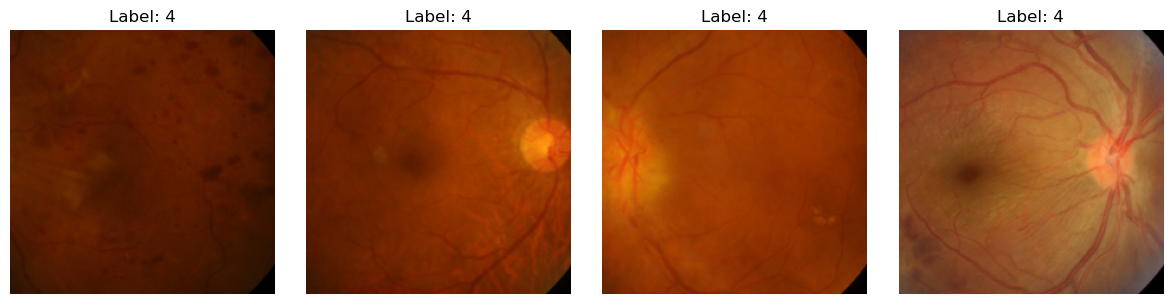

In [ ]:
images, labels = next(iter(test_loader))

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    img_np = denormalize(images[i])
    axes[i].imshow(img_np)   
    axes[i].set_title(f'Label: {labels[i].item()}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

### Full ft

In [ ]:
# There is no need for chaning the model when preparing for FT. The last layer has
# already been changed in the load_fresh_model function.
def prepare_full_ft(model):
    return model

### LoRA

In [ ]:
class LoRAConv2d(nn.Module):
    def __init__(self, original_conv, rank, alpha=1.0):
        super(LoRAConv2d,self).__init__()
        
        self.original_conv = original_conv
        for param in self.original_conv.parameters():
            param.requires_grad = False   

        self.rank = rank
        self.alpha = alpha

        in_channels = original_conv.in_channels
        out_channels = original_conv.out_channels
        kernel_size = original_conv.kernel_size

        self.stride = original_conv.stride
        self.padding = original_conv.padding
        self.dilation = original_conv.dilation
        self.groups = original_conv.groups
        
        self.A = nn.Parameter(torch.randn(rank ,
                                          (in_channels * kernel_size[0] * kernel_size[1] // self.groups))*0.01)
        
        self.B = nn.Parameter(torch.zeros(out_channels, rank))
    def forward(self,x):
        out_orig = self.original_conv(x)
        
        delta_weight = (self.B @ self.A).view(
            self.original_conv.weight.shape
        ) * (self.alpha / self.rank)
        
        out_lora = F.conv2d(
            x, delta_weight,
            bias=None,  
            stride=self.stride,
            padding=self.padding,
            dilation=self.dilation,
            groups=self.groups
        )
        
        return out_orig + out_lora
        

In [ ]:
def prepare_lora(model, rank=4):
    for param in model.parameters():
        param.requires_grad = False
    
    for name, module in model.named_children():
        if name == 'layer3' or name == 'layer4':
            replace_convs_in_module(module, rank)
    model.fc = LoRALinear(model.fc, rank)
    return model

def replace_convs_in_module(module, rank, alpha=1.0):
    for name, child in module.named_children():
        if isinstance(child, nn.Conv2d):
            setattr(module, name, LoRAConv2d(child, rank=rank, alpha=alpha))
        else:
            replace_convs_in_module(child, rank, alpha)
    

### Adapter

In [ ]:
class ConvAdapter(nn.Module):
    def __init__(self, in_channels:int, bottleneck_dim:int):
        super(ConvAdapter,self).__init__()
        self.down = nn.Conv2d(in_channels, bottleneck_dim, kernel_size=1, bias=True)
        self.up = nn.Conv2d(bottleneck_dim, in_channels, kernel_size=1, bias=True)

        nn.init.zeros_(self.up.weight)
        nn.init.zeros_(self.up.bias)
        
    def forward(self, x):
        residual = x
        x = self.down(x)
        x = F.relu(x)
        x = self.up(x)
        return x + residual

In [ ]:
def prepare_adapter(model, bottleneck=64):
    for param in model.parameters():
        param.requires_grad = False
    stage_names = ['layer1', 'layer2', 'layer3', 'layer4']
    for name in stage_names:
        stage = getattr(model, name)
        out_channels = stage[-1].conv3.out_channels  
        setattr(model, name, nn.Sequential(
            stage,
            ConvAdapter(out_channels, bottleneck)
        ))
    adapter = Adapter(2048, bottleneck_dim=64)
    model.fc = nn.Sequential(adapter, model.fc)
    return model
    

### LoRA + Adapter

In [ ]:
def prepare_lora_adapter(model, rank=4, bottleneck=64):
    for param in model.parameters():
        param.requires_grad = False

    for name, module in model.named_children():
        if name == 'layer3' or name == 'layer4':
            replace_convs_in_module(module, rank)

    model.fc = LoRALinear(model.fc, rank)

    stage_out_channels = {
        'layer1': 256,
        'layer2': 512,
        'layer3': 1024,
        'layer4': 2048
    }
    for name in ['layer1', 'layer2', 'layer3', 'layer4']:
        stage = getattr(model, name)
        out_ch = stage_out_channels[name]
        conv_adapter = ConvAdapter(out_ch, bottleneck)
        setattr(model, name, nn.Sequential(stage, conv_adapter))

    linear_adapter = Adapter(2048, bottleneck_dim=bottleneck)
    model.fc = nn.Sequential(linear_adapter, model.fc)

    return model


### Train And Evaluate Loop

In [ ]:
def train_and_evaluate(model,
                       train_loader,
                       test_loader,
                       method_name: str,
                       epochs: int = 20,
                       lr: float = 5e-5) -> dict:
    model = model.to(device)
    print(f"Starting training of {method_name} on {device}")
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    train_losses = []
    test_accuracies = []
    best_test_acc = 0.0
    
    start_time = time.time()
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        num_batches = 0
        
        for images, labels in tqdm(train_loader,
                                   desc=f'{method_name} Epoch {epoch+1}/{epochs}',
                                   leave=False):
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            num_batches += 1
            
        avg_train_loss = total_loss / num_batches
        train_losses.append(avg_train_loss)
        
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        test_acc = 100.0 * correct / total
        test_accuracies.append(test_acc)
        
        if test_acc > best_test_acc:
            best_test_acc = test_acc
        
        print(f"{method_name} | Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Test Acc: {test_acc:.2f}%")
    
    training_time = time.time() - start_time
    
    return {
        'method': method_name,
        'train_losses': train_losses,
        'test_accuracies': test_accuracies,
        'best_test_acc': best_test_acc,
        'total_params': total_params,
        'trainable_params': trainable_params,
        'training_time_sec': training_time
    }
    

In [ ]:
full_ft_model = prepare_full_ft(load_fresh_model(5))
full_ft_result = train_and_evaluate(full_ft_model,
                                    train_loader,
                                    test_loader,
                                    "Full-FT")
print(full_ft_result)

/tmp/ipykernel_2322801/2270352711.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("resnet50.pth", map_location='cpu')


Starting training of Full-FT on cuda


Full-FT | Epoch 1/20 | Train Loss: 1.2748 | Test Acc: 49.51%


Full-FT | Epoch 2/20 | Train Loss: 1.0471 | Test Acc: 57.28%


Full-FT | Epoch 3/20 | Train Loss: 0.9468 | Test Acc: 58.25%


...

Full-FT | Epoch 16/20 | Train Loss: 0.5848 | Test Acc: 51.46%


Full-FT | Epoch 17/20 | Train Loss: 0.4545 | Test Acc: 58.25%


Full-FT | Epoch 18/20 | Train Loss: 0.5580 | Test Acc: 55.34%


Full-FT | Epoch 19/20 | Train Loss: 0.5006 | Test Acc: 54.37%


Full-FT | Epoch 20/20 | Train Loss: 0.4165 | Test Acc: 54.37%
{'method': 'Full-FT', 'train_losses': [1.274810111293426, 1.0470688125261893, 0.9468361609257184, 0.9011241598771169, 0.8365490247423832, 0.7433277872892526, 0.7449967137609537, 0.7725232638991796, 0.6826132747989434, 0.6826621443033218, 0.6091992170191728, 0.738873306948405, 0.5411642918793055, 0.6433167022008163, 0.48689050470980316, 0.5848250303130883, 0.4545224036734838, 0.5579986629577783, 0.5006328282447962, 0.4165307001139109], 'test_accuracies': [49.51456310679612, 57.28155339805825, 58.25242718446602, 61.16504854368932, 64.07766990291262, 53.398058252427184, 59.22330097087379, 59.22330097087379, 61.16504854368932, 60.19417475728155, 57.28155339805825, 48.54368932038835, 48.54368932038835, 48.54368932038835, 51.45631067961165, 51.45631067961165, 58.25242718446602, 55.33980582524272, 54.36893203883495, 54.36893203883495], 'best_test_acc': 64.07766990291262, 'total_params': 23518277, 'trainable_params': 23518277, 'trai

In [ ]:
lora_model = prepare_lora(load_fresh_model(5))
lora_result = train_and_evaluate(lora_model,
                                    train_loader,
                                    test_loader,
                                    "LoRA")
print(lora_result)

/tmp/ipykernel_2322801/2270352711.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("resnet50.pth", map_location='cpu')


Starting training of LoRA on cuda


LoRA | Epoch 1/20 | Train Loss: 1.7349 | Test Acc: 10.68%


LoRA | Epoch 2/20 | Train Loss: 1.7370 | Test Acc: 11.65%


LoRA | Epoch 3/20 | Train Loss: 1.6980 | Test Acc: 16.50%


...

LoRA | Epoch 16/20 | Train Loss: 1.1429 | Test Acc: 56.31%


LoRA | Epoch 17/20 | Train Loss: 1.1420 | Test Acc: 58.25%


LoRA | Epoch 18/20 | Train Loss: 1.1103 | Test Acc: 59.22%


LoRA | Epoch 19/20 | Train Loss: 1.0880 | Test Acc: 57.28%


LoRA | Epoch 20/20 | Train Loss: 1.1267 | Test Acc: 59.22%
{'method': 'LoRA', 'train_losses': [1.7349121570587158, 1.7370188282086299, 1.6979931432467241, 1.6397267534182622, 1.5686682027119856, 1.4852125873932471, 1.425347442810352, 1.3533184757599463, 1.2856993354283845, 1.2547390323418837, 1.2233088566706731, 1.1882534199036086, 1.1642290479861772, 1.1716946512460709, 1.1329924911260605, 1.1428938187085664, 1.1419763209728093, 1.1103155761957169, 1.0880110321136622, 1.1266900427066362], 'test_accuracies': [10.679611650485437, 11.650485436893204, 16.50485436893204, 25.24271844660194, 30.097087378640776, 32.03883495145631, 33.980582524271846, 40.77669902912621, 42.71844660194175, 47.57281553398058, 50.48543689320388, 51.45631067961165, 58.25242718446602, 57.28155339805825, 61.16504854368932, 56.310679611650485, 58.25242718446602, 59.22330097087379, 57.28155339805825, 59.22330097087379], 'best_test_acc': 61.16504854368932, 'total_params': 23784537, 'trainable_params': 266260, 'training

In [ ]:
adapter_model = prepare_adapter(load_fresh_model(5))
adapter_result = train_and_evaluate(adapter_model,
                                    train_loader,
                                    test_loader,
                                    "Adapter")
print(adapter_result)

/tmp/ipykernel_2322801/2270352711.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("resnet50.pth", map_location='cpu')


Starting training of Adapter on cuda


Adapter | Epoch 1/20 | Train Loss: 1.5232 | Test Acc: 32.04%


Adapter | Epoch 2/20 | Train Loss: 1.4529 | Test Acc: 41.75%


Adapter | Epoch 3/20 | Train Loss: 1.3956 | Test Acc: 42.72%


...

Adapter | Epoch 16/20 | Train Loss: 0.9917 | Test Acc: 57.28%


Adapter | Epoch 17/20 | Train Loss: 0.9840 | Test Acc: 63.11%


Adapter | Epoch 18/20 | Train Loss: 0.9925 | Test Acc: 62.14%


Adapter | Epoch 19/20 | Train Loss: 1.0225 | Test Acc: 61.17%


Adapter | Epoch 20/20 | Train Loss: 0.9791 | Test Acc: 59.22%
{'method': 'Adapter', 'train_losses': [1.5232141338861906, 1.4529350033173194, 1.3955509868951945, 1.3042672333809047, 1.2450550072468245, 1.1709340398128216, 1.1174858132233987, 1.1216195248640501, 1.0980635594863157, 1.0213262427311678, 1.0532849499812493, 1.0500560861367445, 1.0388118108877769, 0.9746285333083227, 0.9945483689124768, 0.9916779146744654, 0.9839841757829373, 0.9924639933384382, 1.0225398322710624, 0.9791429535700724], 'test_accuracies': [32.03883495145631, 41.74757281553398, 42.71844660194175, 43.689320388349515, 48.54368932038835, 48.54368932038835, 50.48543689320388, 44.66019417475728, 56.310679611650485, 56.310679611650485, 57.28155339805825, 60.19417475728155, 59.22330097087379, 59.22330097087379, 53.398058252427184, 57.28155339805825, 63.10679611650485, 62.13592233009709, 61.16504854368932, 59.22330097087379], 'best_test_acc': 63.10679611650485, 'total_params': 24278149, 'trainable_params': 759872, 'tr

In [ ]:
combined = prepare_lora_adapter(load_fresh_model(5))
combined_result = train_and_evaluate(combined,
                                    train_loader,
                                    test_loader,
                                    "LoRA-Adapter")
print(combined_result)

/tmp/ipykernel_2322801/2270352711.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("resnet50.pth", map_location='cpu')


Starting training of LoRA-Adapter on cuda


LoRA-Adapter | Epoch 1/20 | Train Loss: 1.4918 | Test Acc: 39.81%


LoRA-Adapter | Epoch 2/20 | Train Loss: 1.4355 | Test Acc: 32.04%


LoRA-Adapter | Epoch 3/20 | Train Loss: 1.3527 | Test Acc: 39.81%


...

LoRA-Adapter | Epoch 16/20 | Train Loss: 0.9441 | Test Acc: 57.28%


LoRA-Adapter | Epoch 17/20 | Train Loss: 0.9353 | Test Acc: 61.17%


LoRA-Adapter | Epoch 18/20 | Train Loss: 1.0005 | Test Acc: 62.14%


LoRA-Adapter | Epoch 19/20 | Train Loss: 0.9899 | Test Acc: 61.17%


LoRA-Adapter | Epoch 20/20 | Train Loss: 0.9043 | Test Acc: 59.22%
{'method': 'LoRA-Adapter', 'train_losses': [1.4918140493906462, 1.4354721078505883, 1.3526564366542375, 1.2358467326714442, 1.1422110635500689, 1.1291571259498596, 1.1217446281359746, 1.068201835338886, 0.9981721868881812, 1.0498072705589807, 1.0410035223915026, 0.9961670213020765, 1.0122469308284612, 0.9968939538185413, 0.9634350400704604, 0.9440817213975466, 0.9352535783098295, 1.0005274655727239, 0.9898883975469149, 0.9042800917075231], 'test_accuracies': [39.80582524271845, 32.03883495145631, 39.80582524271845, 44.66019417475728, 50.48543689320388, 51.45631067961165, 59.22330097087379, 58.25242718446602, 55.33980582524272, 62.13592233009709, 57.28155339805825, 60.19417475728155, 52.42718446601942, 61.16504854368932, 60.19417475728155, 57.28155339805825, 61.16504854368932, 62.13592233009709, 61.16504854368932, 59.22330097087379], 'best_test_acc': 62.13592233009709, 'total_params': 24544409, 'trainable_params': 102613

In [ ]:
all_results = [
    full_ft_result,
    lora_result,
    adapter_result,
    combined_result
]
data = []
for res in all_results:
    total_params = res['total_params']
    trainable = res['trainable_params']
    percent = (trainable / total_params) * 100
    data.append({
        'Method': res['method'],
        'Trainable Params': trainable,
        '% of Total': round(percent, 2),
        'Best Test Acc (%)': round(res['best_test_acc'], 2),
        'Train Time (s)': round(res['training_time_sec'], 2)
    })

df = pd.DataFrame(data)
print("\n" + "="*80)
print("COMPARISON TABLE")
print(df.to_string(index=False))
print("="*80)




COMPARISON TABLE
      Method  Trainable Params  % of Total  Best Test Acc (%)  Train Time (s)
     Full-FT          23518277      100.00              64.08          639.76
        LoRA            266260        1.12              61.17          664.82
     Adapter            759872        3.13              63.11          864.34
LoRA-Adapter           1026132        4.18              62.14          858.18


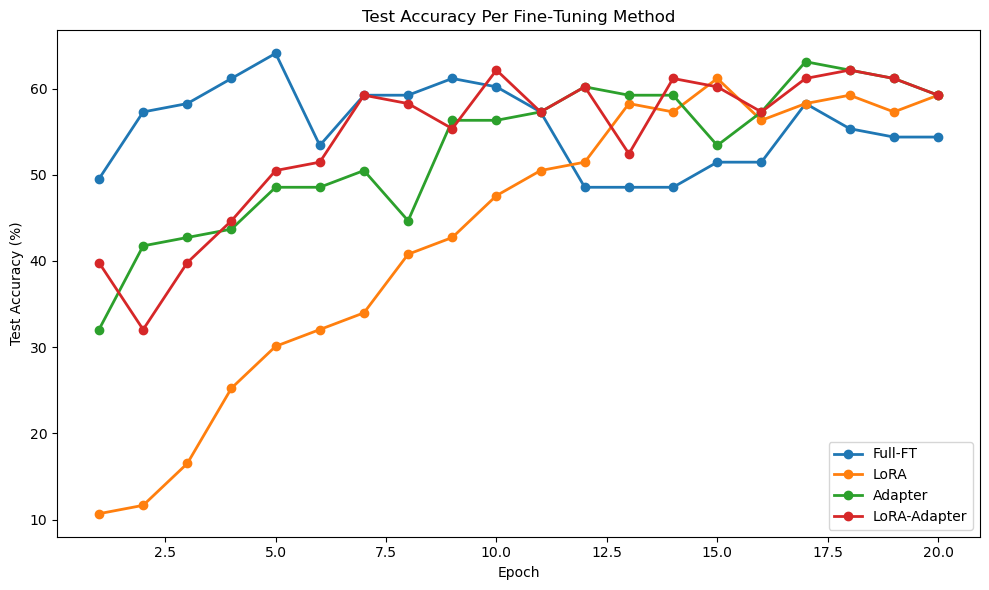

In [ ]:
plt.figure(figsize=(10, 6))
for res in all_results:
    accuracies = res['test_accuracies']
    epochs = range(1, len(accuracies) + 1)
    plt.plot(epochs, accuracies, marker='o', linewidth=2, label=res['method'])
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.title('Test Accuracy Per Fine‑Tuning Method')
plt.legend()
plt.tight_layout()
plt.show()



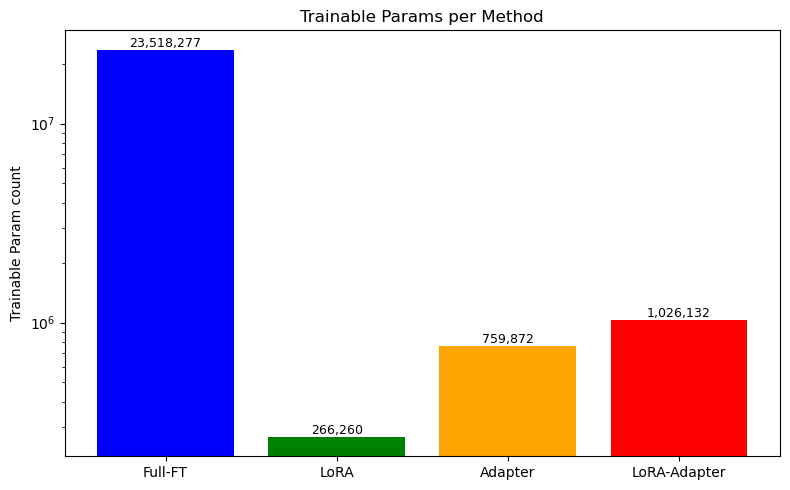

In [ ]:
plt.figure(figsize=(8, 5))
methods = [res['method'] for res in all_results]
trainable_counts = [res['trainable_params'] for res in all_results]
bars = plt.bar(methods, trainable_counts, color=['blue', 'green', 'orange', 'red'])
plt.ylabel('Trainable Param count')
plt.title('Trainable Params per Method')
plt.yscale('log')
for bar, count in zip(bars, trainable_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{count:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
def save_trainable_params(model, method_name):
    trainable_state = {k: v.cpu() for k, v in model.named_parameters() if v.requires_grad}
    torch.save(trainable_state, f"{method_name}_trainable_params.pth")


In [ ]:
all_models = [(full_ft_model,"Full-FT"),
              (lora_model,"LoRA"),
              (adapter_model,"Adapter"),
              (combined,"LoRA-Adapter")]
for model in all_models:
    save_trainable_params(model[0],model[1])

## Theoretical Questions

### Q1.

The idea behind this is the fact that at the start of learning, we don't want LoRA or Adapters to change the behaviour of the pretrained netowrk. At the start we want the added part to the network to act as a sort of Identity function. Now as the training commences we want the added part in these 2 methods to learn. In the following part I will analyze the gradient flow in LoRA and Adapter showing that setting B and the second linear layer to 0 at the start guarantees perfect gradient flow while setting A or the first linear layer disrupts learning.

**LoRA** : 

$$
y = Wx + B(Ax)
$$
$$
\frac{\partial{L}}{\partial{B}} = \frac{\partial{L}}{\partial{y}}\cdot \frac{\partial{y}}{\partial{B}} \longrightarrow = \frac{\partial{L}}{\partial{y}}\cdot Ax
$$
$$
\frac{\partial{L}}{\partial{A}} = \frac{\partial{L}}{\partial{y}}\cdot \frac{\partial{y}}{\partial{A}} \longrightarrow = B^Tg_{upstream}x^T
$$

Now in the above equation if B is zero at the start and A is initialized with random values, A will not update with the gradients and B will be the only changing Parameter. However after B has changed, A will start to adjust too. On the other hand if we set A to 0 and B to a non zero value, B will not be updated with the gradients (As you can see the update term of B is dependent on A) and the value of A will change based on the random init values of B. If both A and B are set to random values at start, There will be a non zero noise added to the pretrained model, now this noise can be large, making the model start from a suboptimal point in space. On the other hand the gradient update for both matrices will be non 0 from the start making the updates coupled and messy.

**Adapter** :

The above explanation is correct for adapters too. If we rewrite the update equation for the first and second linear layers, the second layer updates based on the value of the first layer. So if the first layer is set to 0 the second layer will learn nothing what so ever. While if the second layer is set to 0 and the first one randomly initialized, The model will have stable gradient flow and learn based on the input data.

### Q2.

**Without LoRA** : 

$$
Params = 256 \times 128 \times 3 \times 3 = 294912
$$

**With LoRA** :

$$
Params = 256 \times 4 + 4 \times 128 \times 3 \times 3 = 5632
$$

$$
ratio = \frac{5632}{294912} = 0.019
$$

### Q3.

While adding the least amount of parameters, LoRA has reached the same level of accuracy as all the other 3 models. So I think in this scenario LoRA is the clear winner. Now comparing these 2 methods:

**Inference Delay** : Adapters generally introduce inference latency, the reason for this latency is the fact that adding a new sequential layer to the network requires the network to go trough the newly added layer in the forward pass, while LoRA does not suffer from the said problem. The update matrix in LoRA has virtually no time overhead. This can be seen in the experiment results too.

**Model Expressiveness** : Adapters introduce non-linearity between the 2 linear layers while LoRA has no non-linearity, meaning Adapters are more expresive than LoRA.

In modern use cases the zero inference delay of LoRA is cosidered more important than the expressiveness of adapters. Meaning for most of the time LoRA is the go to choice for fine-tuning models, while Adapters are generally used when we require non linearity to acheive good results and the linear transformation of LoRA is not enough.

### Comparision of param size
The following table shows the param size of the 4 methods :

| Method | Saved weight size |
|----------|----------|
| Full-FT    | 91918 KB  |
| LoRA    | 1059 KB  |
| Adapter    | 2975 KB  |
| LoRA + Adapter | 4034 KB|